# Database Summary & Statistics
This page provides a comprehensive overview of the **Iggytop** database created by the create_anndata.py pipeline. It reports details on the distribution of data sources, species, MHC information, and receptor quality.

This report summarizes the processed and deduplicated AIRR data used for downsteam analysis and knowledge graph construction.
If you want to reporodice this, please run create_anndata.py to generate the data.

In [1]:
import scanpy as sc
import scirpy as ir
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
from pathlib import Path
import json
from urllib.request import Request, urlopen

# Set Plotly to render as static SVG for better compatibility with Sphinx/MyST-NB
import plotly.io as pio
pio.renderers.default = "svg" # Use "png" if svg still causes issues

# Config
# Use existing release_dir variable from the notebook
release_dir = "./../../../releases"
Path(release_dir).mkdir(parents=True, exist_ok=True)

api_url = "https://api.github.com/repos/biocypher/iggytop/releases/latest"
req = Request(api_url, headers={"User-Agent": "iggytop-notebook"})
with urlopen(req) as resp:
    release = json.load(resp)

for asset in release.get("assets", []):
    filename = asset["name"]
    download_url = asset["browser_download_url"]
    out_path = Path(release_dir) / filename

    if out_path.exists() and out_path.stat().st_size == asset.get("size", -1):
        print(f"Skipping {filename} (already present)")
        continue

    req_file = Request(download_url, headers={"User-Agent": "iggytop-notebook"})
    with urlopen(req_file) as src, open(out_path, "wb") as dst:
        dst.write(src.read())

    print(f"Downloaded: {filename}")
dedup_path = f"{release_dir}/deduplicated_anndata.h5ad"
merged_path = f"{release_dir}/merged_anndata.h5ad"
pd.set_option('display.max_colwidth', None)

# Load data
adata_dedup = sc.read_h5ad(dedup_path)
try:
    adata_merged = sc.read_h5ad(merged_path)
except FileNotFoundError:
    adata_merged = adata_dedup.copy() # Fallback if merged is not available

# Pre-calculate metadata
meta = adata_dedup.uns.get("iggytop_metadata", {})

Skipping deduplicated_airr_cells.json.gz (already present)
Skipping deduplicated_anndata.h5ad (already present)
Skipping merged_airr_cells.json.gz (already present)
Skipping merged_anndata.h5ad (already present)
Skipping metadata.json (already present)
Skipping RELEASE_NOTES.md (already present)


/home/helen/projectsZHAW/VT1/iggytop/.venv/lib/python3.12/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


## Executive Summary
A snapshot of the current database size and content after cross-database deduplication.


In [2]:
n_total = adata_merged.n_obs
n_unique = adata_dedup.n_obs
ratio = n_unique / (n_total if n_total > 0 else 1)
n_epitopes = adata_dedup.obs['epitope_sequence'].nunique()
n_pmids = adata_dedup.obs['PMID'].nunique()

version = release.get('tag_name', 'latest')
release_url = release.get('html_url', 'https://github.com/biocypher/iggytop/releases')
release_date = meta.get('release_date', 'unknown')

html_summary = f"""
<p>The database version used here is: <strong><a href="{release_url}">{version}</a></strong> (released on {release_date}).</p>

<div style="display: flex; justify-content: space-around; background-color: #f8f9fa; border: 1px solid #dee2e6; border-radius: 8px; padding: 20px;">
    <div style="text-align: center;">
        <h3 style="margin-bottom: 5px; color: #333333;">Total Receptors</h3>
        <p style="font-size: 24px; font-weight: bold; color: #007bff;">{n_total:,}</p>
    </div>
    <div style="text-align: center;">
        <h3 style="margin-bottom: 5px; color: #333333;">Unique Entries</h3>
        <p style="font-size: 24px; font-weight: bold; color: #28a745;">{n_unique:,}</p>
        <span style="font-size: 14px; color: #6c757d;">Reduction by {(1-ratio)*100:.1f}%</span>
    </div>
    <div style="text-align: center;">
        <h3 style="margin-bottom: 5px; color: #333333;">Unique Epitopes</h3>
        <p style="font-size: 24px; font-weight: bold; color: #fd7e14;">{n_epitopes:,}</p>
    </div>
    <div style="text-align: center;">
        <h3 style="margin-bottom: 5px; color: #333333;">Publications</h3>
        <p style="font-size: 24px; font-weight: bold; color: #6f42c1;">{n_pmids:,}</p>
    </div>
</div>

<p style="margin-top: 15px;"><em>Note: If you find this report to be outdated or encounter any issues with the data, please <a href="https://github.com/biocypher/iggytop/issues">open an issue on GitHub</a>.</em></p>
"""
display(HTML(html_summary))

## Source and Organism Distributions
We track where the data originates and the species diversity. Many entries are found in multiple databases simultaneously.

Note: you may need to restart the kernel to use updated packages.


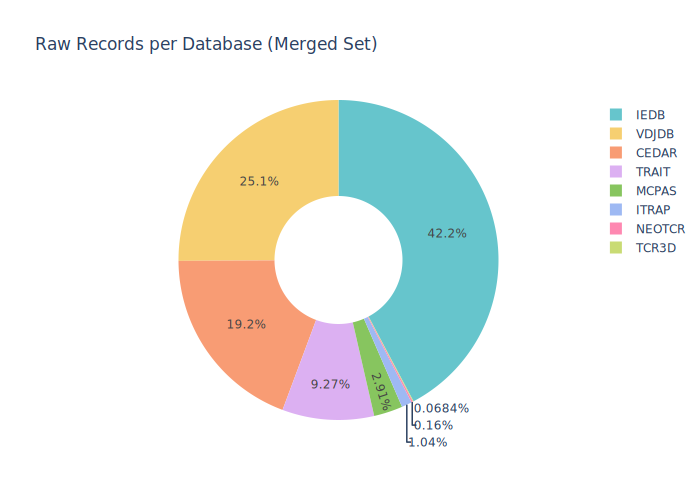

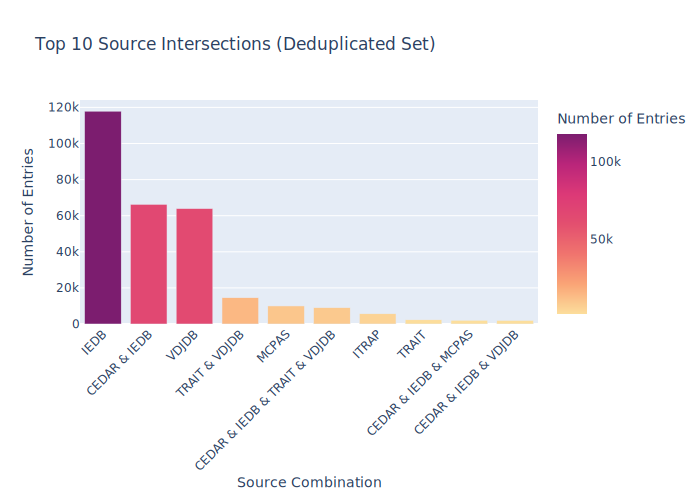

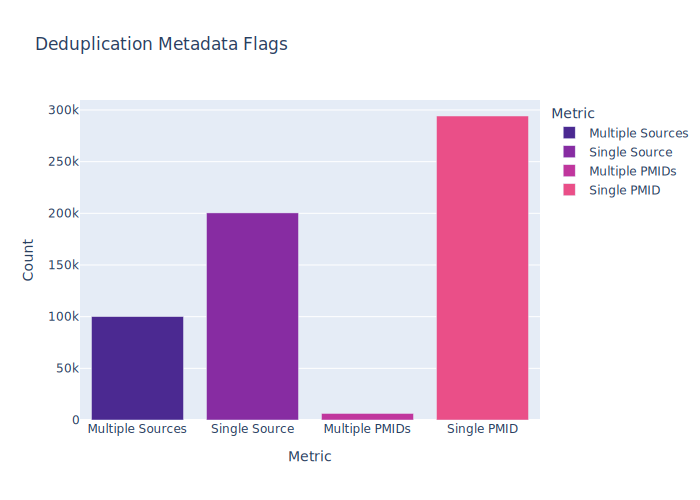

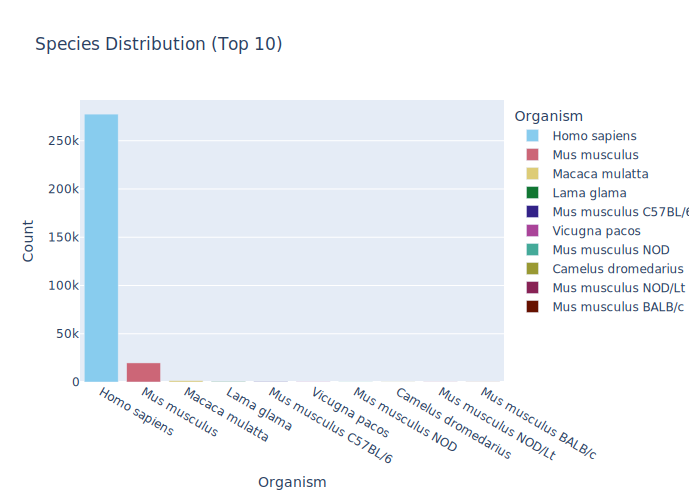

In [3]:
# %pip install --upgrade kaleido
# 1. Merged Data Distribution (Before Deduplication)
merged_source_counts = adata_merged.obs['source'].value_counts().reset_index()
merged_source_counts.columns = ['Source', 'Raw Count']

fig_merged = px.pie(merged_source_counts, names='Source', values='Raw Count', 
                  title="Raw Records per Database (Merged Set)",
                  hole=0.4, color_discrete_sequence=px.colors.qualitative.Pastel)
fig_merged.show()

# 2. Overlap Analysis (Deduplicated Data)
# Each entry can have multiple sources separated by '|'
sources_list = adata_dedup.obs['source'].str.split('|')

# Create binary matrix for UpSet plot-like visualization
all_unique_sources = sorted(list(set([s for sublist in sources_list for s in sublist])))
overlap_matrix = pd.DataFrame(0, index=adata_dedup.obs_names, columns=all_unique_sources)

for idx, sources in zip(adata_dedup.obs_names, sources_list):
    overlap_matrix.loc[idx, sources] = 1

# Calculate intersection sizes
intersection_counts = overlap_matrix.groupby(all_unique_sources).size().reset_index(name='count')
intersection_counts['intersection_name'] = intersection_counts[all_unique_sources].apply(
    lambda row: " & ".join([col for col, val in row.items() if val == 1 and col != 'count']), axis=1
)
intersection_counts = intersection_counts.sort_values('count', ascending=False).head(10)

fig_overlap = px.bar(intersection_counts, x='intersection_name', y='count',
                   title="Top 10 Source Intersections (Deduplicated Set)",
                   labels={'intersection_name': 'Source Combination', 'count': 'Number of Entries'},
                   color='count', color_continuous_scale='Sunsetdark')
fig_overlap.update_layout(xaxis_tickangle=-45)
fig_overlap.show()

# Metadata for Multi-Source/PMID Analysis
overlap_counts = pd.DataFrame({
    'Metric': ['Multiple Sources', 'Single Source', 'Multiple PMIDs', 'Single PMID'],
    'Count': [
        adata_dedup.obs['source'].str.contains('|', regex=False).sum(),
        (~adata_dedup.obs['source'].str.contains('|', regex=False)).sum(),
        adata_dedup.obs['PMID'].str.contains('|', regex=False).sum(),
        (~adata_dedup.obs['PMID'].str.contains('|', regex=False)).sum()
    ]
})

fig_overlap = px.bar(overlap_counts, x='Metric', y='Count', 
                    title="Deduplication Metadata Flags",
                    color='Metric', color_discrete_sequence=px.colors.sequential.Agsunset)
fig_overlap.show()

# 3. Species Distribution
species_df = adata_dedup.obs['source_organism'].value_counts().reset_index()
species_df.columns = ['Organism', 'Count']
# Show top 10 species only
species_df_top10 = species_df.head(10)
fig_spec = px.bar(species_df_top10, x='Organism', y='Count', color='Organism', 
                 title="Species Distribution (Top 10)", color_discrete_sequence=px.colors.qualitative.Safe)
# Update layout to fix clipped legend at bottom and rotate labels
fig_spec.update_layout(
    margin=dict(b=100),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)
fig_spec.show()

## MHC Context Availability
Availability of MHC class and gene information varies significantly by database origin.
We visualize the proportion of records containing MHC Class I or Class II information.

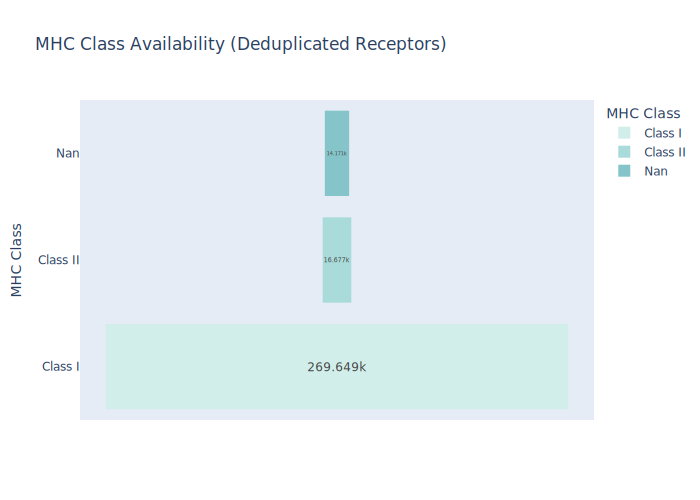

In [4]:
# Normalize MHC_class strings (handle None or nan)
def categorize_mhc(x):
    if 'I' == x:
        return 'Class I'
    elif 'II' == x:
        return 'Class II'
    elif 'nan' == x or x == 'None':
        return 'Nan'
    else:
        return 'Unknown/Other'

adata_dedup.obs['MHC_category'] = adata_dedup.obs['MHC_class'].apply(categorize_mhc)    
mhc_stats = adata_dedup.obs['MHC_category'].value_counts().reset_index()
mhc_stats.columns = ['MHC Class', 'Count']

# Funnel plot for MHC Class Coverage
fig_mhc = px.funnel(mhc_stats, y='MHC Class', x='Count', color='MHC Class', 
                   title="MHC Class Availability (Deduplicated Receptors)",
                   color_discrete_sequence=px.colors.sequential.Teal)
fig_mhc.show()


## TCR Chain Configuration (QC)
Using the `scirpy.tl.chain_qc` tool, we categorize the structural quality of the receptors. A high proportion of "Productive" pairs (Alpha+Beta) indicates better biological quality for structural modeling.

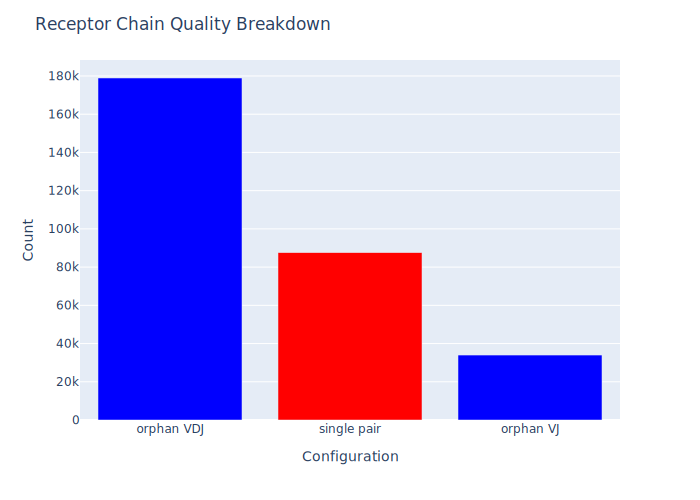

In [5]:
# Run QC
ir.tl.chain_qc(adata_dedup, inplace=True)
qc_df = adata_dedup.obs['chain_pairing'].value_counts().reset_index()
qc_df.columns = ['Configuration', 'Count']

fig_qc = px.bar(qc_df, x='Configuration', y='Count', color='Configuration', color_discrete_sequence=px.colors.sequential.Bluered)
fig_qc.update_layout(title_text="Receptor Chain Quality Breakdown", showlegend=False)
fig_qc.show()

## Sequence Distributions and Coverage
CDR3 (junction_aa) and Epitope lengths for biological consistency validation. 
Consistent distributions across sources suggest cross-database compatibility.

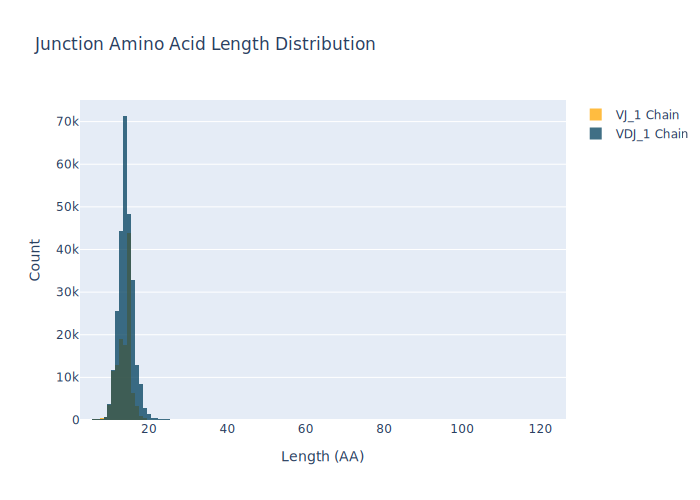

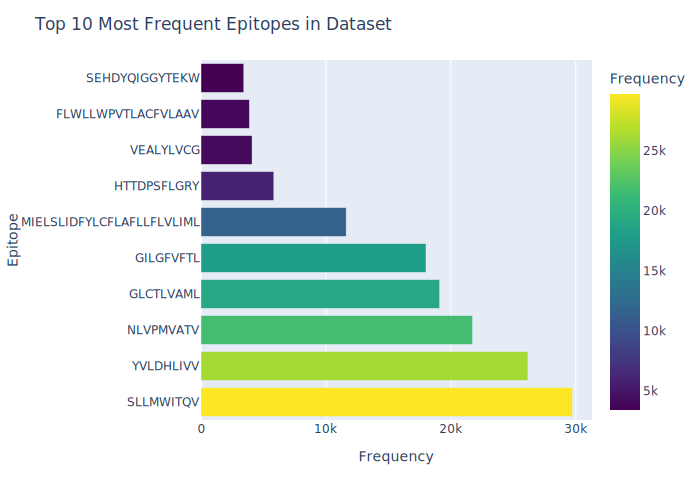

In [6]:
with ir.get.airr_context(adata_dedup, ["junction_aa"], chain=["VJ_1", "VDJ_1"]) as m:
    df_len = m.obs.copy()
    # Calculate lengths while ignoring NaN/None
    df_len['VJ_len'] = df_len['VJ_1_junction_aa'].apply(lambda x: len(str(x)) if pd.notna(x) and x != 'None' else np.nan)
    df_len['VDJ_len'] = df_len['VDJ_1_junction_aa'].apply(lambda x: len(str(x)) if pd.notna(x) and x != 'None' else np.nan)

# Histogram plot
fig_len = go.Figure()
fig_len.add_trace(go.Histogram(x=df_len['VJ_len'], name='VJ_1 Chain', marker_color='#ffa600'))
fig_len.add_trace(go.Histogram(x=df_len['VDJ_len'], name='VDJ_1 Chain', marker_color='#003f5c'))
fig_len.update_layout(title_text="Junction Amino Acid Length Distribution", barmode='overlay', xaxis_title="Length (AA)", yaxis_title="Count")
fig_len.update_traces(opacity=0.75)
fig_len.show()

# Top Epitopes
top_ept = adata_dedup.obs['epitope_sequence'].value_counts().head(10).reset_index()
top_ept.columns = ['Epitope', 'Frequency']
fig_ept = px.bar(top_ept, x='Frequency', y='Epitope', orientation='h', color='Frequency', color_continuous_scale='Viridis')
fig_ept.update_layout(title_text="Top 10 Most Frequent Epitopes in Dataset")
fig_ept.show()